In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit, RawFeatureVector

algorithm_globals.random_seed = 42

In [2]:
# Amplitude encoding with a large vector
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

In [23]:
sample_pca_reduced_df = pd.read_csv(r"X_pca_df800.csv")
sample_isomap_reduced_df = pd.read_csv(r"X_isomap_df800.csv")

In [24]:
sample_isomap_reduced_df.shape

(800, 64)

In [25]:
sample_pca_reduced_df.shape

(800, 64)

In [26]:
sample_isomap_reduced_df.head(2)

,iso_0,iso_1,iso_2,iso_3,iso_4,iso_5,iso_6,iso_7,iso_8,iso_9,...,iso_54,iso_55,iso_56,iso_57,iso_58,iso_59,iso_60,iso_61,iso_62,iso_63
0,-53.671696,31.974530,-24.269207,19.209847,14.136245,1.007176,-7.544981,6.892984,24.187482,-19.671826,...,17.529770,-0.488861,6.515017,-10.711217,1.107419,-9.427081,5.073199,-7.731891,-26.742105,0.392372
1,155.376024,-154.436262,209.230539,-128.866146,79.643210,-100.940090,-43.293867,126.229685,-23.773667,38.726918,...,22.316247,-2.885783,2.772488,-18.489251,26.095577,-12.193787,-31.733542,42.559637,-9.496247,-21.525337


In [27]:
sample_pca_reduced_df.head(2)

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,...,pca_54,pca_55,pca_56,pca_57,pca_58,pca_59,pca_60,pca_61,pca_62,pca_63
0,-20.244039,-6.718547,-11.839866,3.007421,4.245244,-3.932463,0.380121,-3.792199,-0.324690,1.13084,...,-4.263460,-3.183433,3.756453,1.945535,-0.347829,-0.425930,3.166405,-2.446840,-1.412551,1.460386
1,39.612205,-9.017961,-9.869754,7.911266,-12.857755,-0.139605,-9.189059,14.995977,-8.147701,-9.10158,...,-1.818266,-7.895065,-1.943329,1.922069,4.046929,-1.499064,4.023561,7.101501,-0.294733,-0.920286


In [28]:
X_isomap = sample_isomap_reduced_df.values.astype(float)
X_isomap

array([[ -53.6716956 ,   31.9745297 ,  -24.26920663, ...,   -7.73189084,
         -26.74210496,    0.39237153],
       [ 155.3760238 , -154.43626227,  209.23053919, ...,   42.55963676,
          -9.49624653,  -21.52533661],
       [ -59.51566191,  -18.81725237,  -19.87393472, ...,   16.12294572,
           4.47644358,   19.42115278],
       ...,
       [ -56.08627424,  -13.20135026,  -30.15196932, ...,   -5.99809375,
          -3.01871741,   20.67019881],
       [ -60.77612672,  -21.23370033,  -38.88927152, ...,   21.36075044,
          15.67440525,   32.50487163],
       [  16.79913123,  212.08375604,  243.88833167, ...,  -24.81525179,
          29.66077471,  -18.4642883 ]])

In [29]:
X_pca = sample_pca_reduced_df.values.astype(float)
X_pca

array([[-20.24403853,  -6.71854693, -11.83986608, ...,  -2.44684049,
         -1.41255105,   1.46038581],
       [ 39.6122053 ,  -9.01796079,  -9.86975353, ...,   7.10150119,
         -0.29473323,  -0.92028645],
       [ -0.9490618 ,  -8.58692863,  10.02665469, ...,   1.87479011,
        -10.83935942,  -0.53568017],
       ...,
       [-17.94227216,  -9.20516314,  -7.49908326, ...,  -5.03717339,
         -3.08102528,   3.80613596],
       [-15.9256278 ,  -9.42942039,  -2.79996573, ...,  -2.79295559,
          2.06066621,   1.41199974],
       [  2.87495928,  35.62286603,   3.99863337, ...,  -0.56846159,
         -1.96584731,   1.34571882]])

In [30]:
# create array of shape (800,2) as the labels (positive [1,0], and negative [0,1])
num_samples = 400
y_one_hot = np.array([[0, 1]] * num_samples + [[1, 0]] * num_samples)
print(y_one_hot.shape)
print(y_one_hot[0:2])
print(y_one_hot[-2:])

(800, 2)
[[0 1]
 [0 1]]
[[1 0]
 [1 0]]


In [31]:
def pad_to_power_of_2(data):
    """Pad data with zeros to the nearest power of 2"""
    next_power = 2 ** int(np.ceil(np.log2(len(data))))
    padded_data = np.zeros(next_power)
    padded_data[:len(data)] = data  # Retaining original values
    return padded_data

In [32]:
# normalizing the training dataset for RawFeatureVector
from numpy.linalg import norm

def normalize(X):
    return np.array([x / norm(x) if norm(x) > 0 else x for x in X])

X_train_norm = normalize(X_pca)
X_train_isomap_norm = normalize(X_isomap)

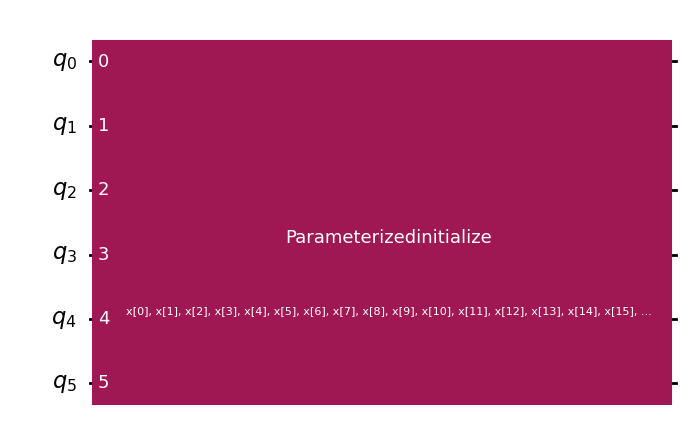

In [33]:
num_features = 64
feature_map = RawFeatureVector(num_features)
display(feature_map.draw(output="mpl"))

In [34]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()


In [35]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()


In [36]:
# construct ansatz, and optimizer
from qiskit.circuit.library import TwoLocal
ansatz = TwoLocal(num_qubits=6, rotation_blocks="ry", entanglement_blocks="cz", reps=1)

In [37]:
# construct variational quantum classifier
vqc_isomap = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


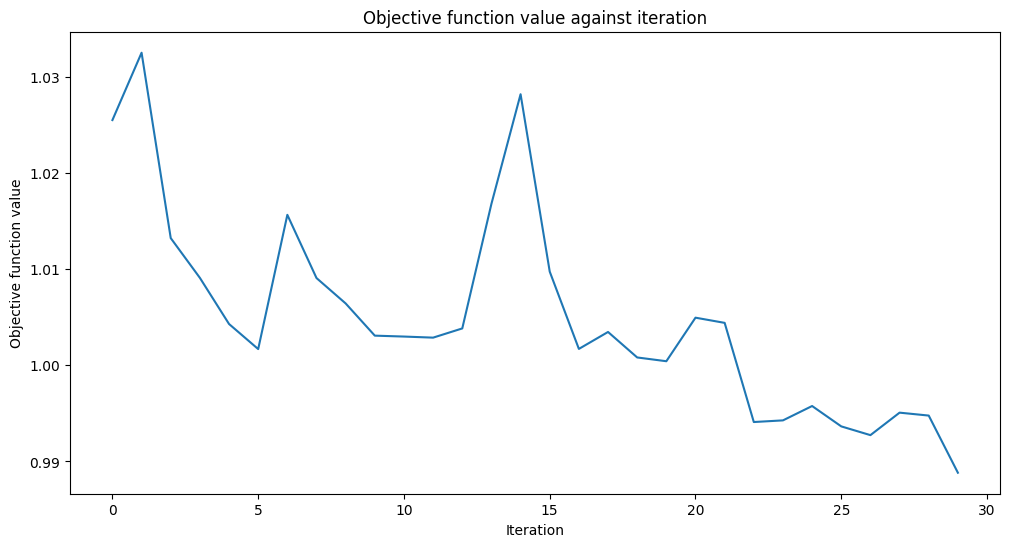

In [38]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to isomap data
vqc_isomap.fit(X_train_isomap_norm, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)


In [39]:
# score classifier
vqc_isomap.score(X_train_norm, y_one_hot)
# evaluate data points
y_predict = vqc_isomap.predict(X_train_norm)

In [41]:
from sklearn.metrics import accuracy_score

# Predict labels for the training set
y_pred = np.argmax(y_predict, axis=1)

# Convert one-hot encoded `y_one_hot` back to class labels
y_true = np.argmax(y_one_hot, axis=1)

# Compute accuracy
acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", acc)


Training Accuracy: 0.525


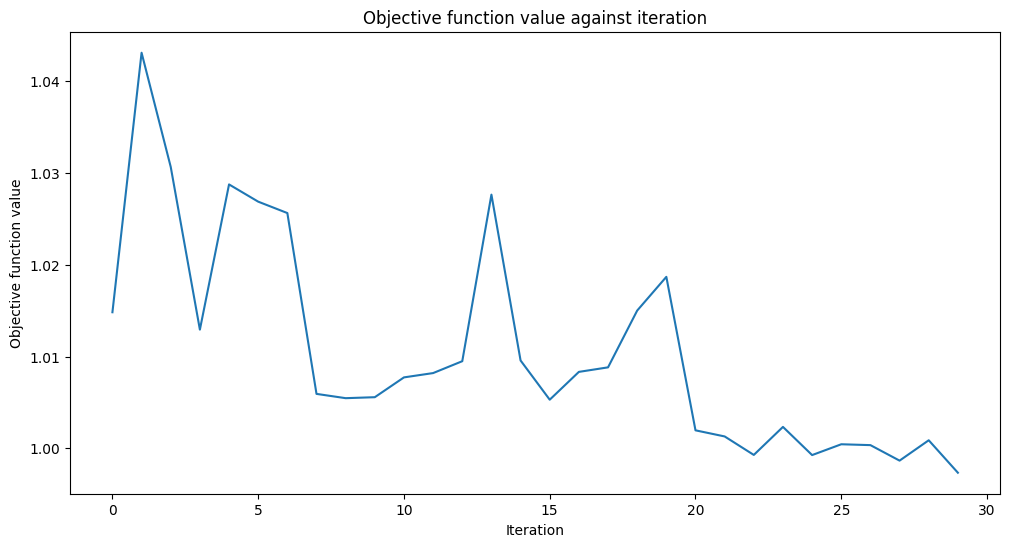

In [20]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to pca data
vqc.fit(X_train_norm, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)


In [42]:
# score classifier
vqc.score(X_train_norm, y_one_hot)
# evaluate data points
y_predict = vqc.predict(X_train_norm)

In [43]:
from sklearn.metrics import accuracy_score

# Predict labels for the training set
y_pred = np.argmax(y_predict, axis=1)

# Convert one-hot encoded `y_one_hot` back to class labels
y_true = np.argmax(y_one_hot, axis=1)

# Compute accuracy
acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", acc)


Training Accuracy: 0.53


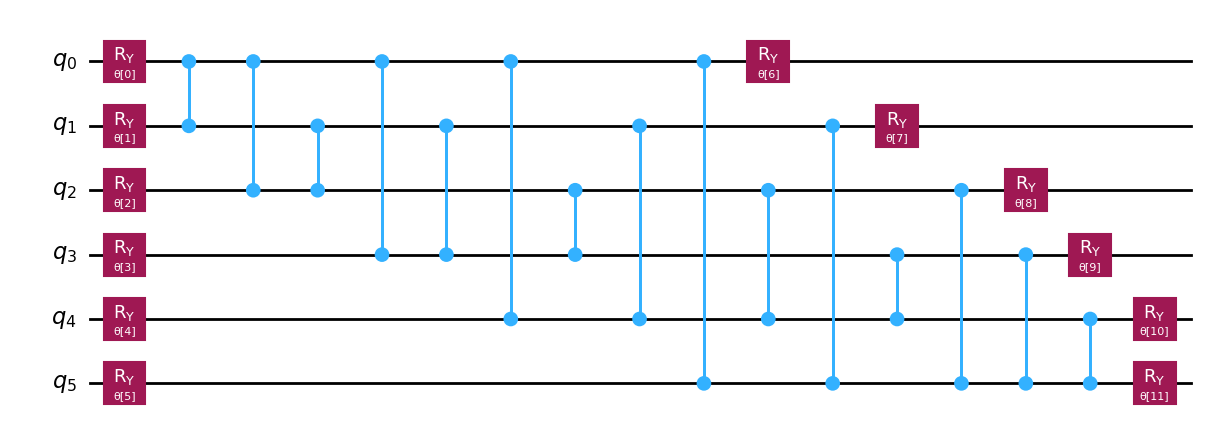

In [45]:
vqc_isomap.ansatz.decompose().draw("mpl")

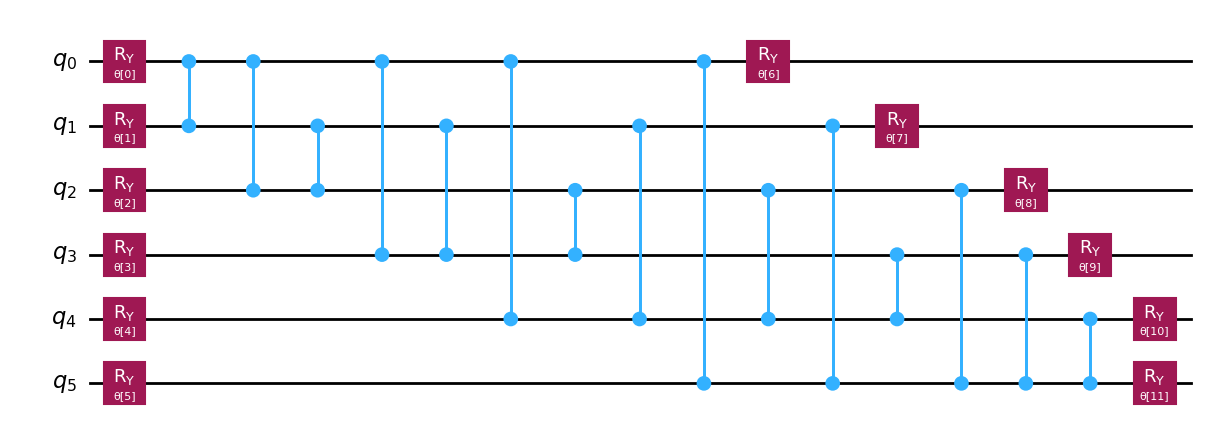

In [44]:
vqc.ansatz.decompose().draw("mpl")

In [15]:
# libraries for classical neural network model 
# !pip install torch
import torch
import torch.nn as nn
import torch.optim as optim

In [16]:
# Convert to float32 for PyTorch
X = sample_pca_reduced_df.values.astype(np.float32)
y = y_one_hot.astype(np.float32)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)
y_labels = torch.argmax(y_tensor, dim=1)  # Convert one-hot to class indices

In [17]:
# Define the model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

# Instantiate model, loss, and optimizer
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

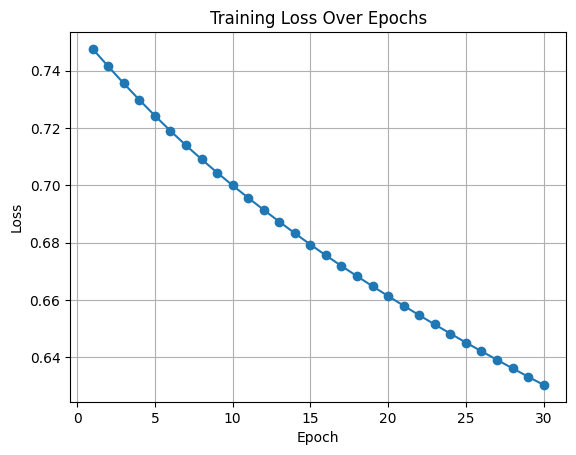

In [18]:
# Store losses for each epoch
losses = []

# Train the model
for epoch in range(30):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())  # Save loss per epoch

# Plot the loss curve
plt.plot(range(1, 31), losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [19]:
# Evaluate on the same data
with torch.no_grad():
    predictions = model(X_tensor)
    correct = (torch.argmax(predictions, dim=1) == y_labels).sum().item()
    total = y_labels.shape[0]
    accuracy = correct / total

print(f"Train/Test accuracy (same set): {accuracy * 100:.2f}%")

Train/Test accuracy (same set): 69.50%


In [46]:
# Convert to float32 for PyTorch
X = sample_isomap_reduced_df.values.astype(np.float32)
y = y_one_hot.astype(np.float32)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)
y_labels = torch.argmax(y_tensor, dim=1)  # Convert one-hot to class indices

In [47]:
# Define the model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

# Instantiate model, loss, and optimizer
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

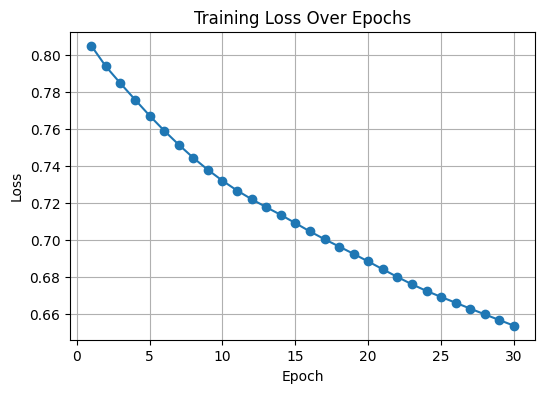

In [48]:
# Store losses for each epoch
losses = []

# Train the model
for epoch in range(30):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())  # Save loss per epoch

# Plot the loss curve
plt.plot(range(1, 31), losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [49]:
# Evaluate on the same data
with torch.no_grad():
    predictions = model(X_tensor)
    correct = (torch.argmax(predictions, dim=1) == y_labels).sum().item()
    total = y_labels.shape[0]
    accuracy = correct / total

print(f"Train/Test accuracy (same set): {accuracy * 100:.2f}%")

Train/Test accuracy (same set): 66.00%
